Basado en el post
***Building a Perceptron from Scratch: A Step-by-Step Guide with Python***
por Marcus Sena

# CONSTRUCCION DE UN PERCEPTRÓN
Aplicado al set de datos IRIS

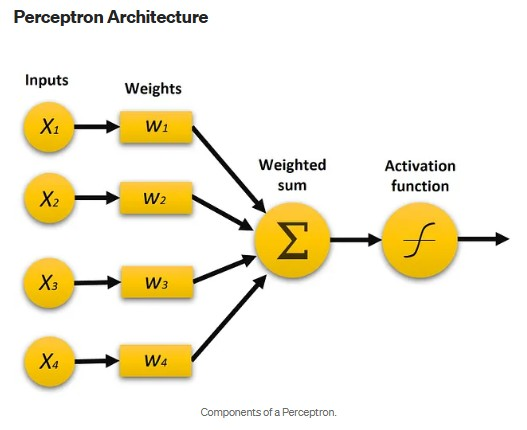

**ENTRADA:** Las características de entrada representan los datos sin procesar que el perceptrón utiliza para tomar decisiones. Definiremos dos entradas (X1, X2) con valores fijos para simplificar la red neuronal. Sin embargo, en aplicaciones reales, la neurona puede utilizar muchas entradas para representar información de entrada diversa.

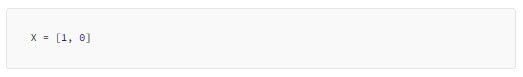

**PESOS**: Aquí generaremos los pesos para componer nuestra red neuronal. Inicialmente generaremos pesos aleatorios pequeños en este ejemplo, pero es importante tener en cuenta que estos pesos se actualizarán cuando se entrene la red. El código a continuación muestra cómo generar dos pesos aleatorios entre -1 y 1 (uno para cada entrada).

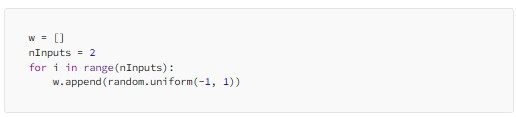

**BIAS :** El término bias (sesgo) es una entrada adicional al perceptrón, que sirve como umbral ajustable. Permite que el perceptrón tome decisiones incluso cuando todas las características de entrada son cero. El sesgo ayuda a controlar la activación del perceptrón. De manera similar, estableceremos el sesgo inicial como un pequeño número aleatorio.

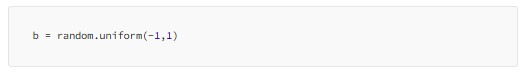

**FUNCION DE ACTIVACIÓN :** La función de activación transforma la suma ponderada de las entradas en una salida binaria. Esta salida es la predicción del perceptrón, que representa una decisión o clasificación. A menudo, queremos que la salida de la función de activación sea 0 o 1.

Una función muy común utilizada con ese propósito es la función sigmoidea, debido a su diferenciabilidad, suavidad y tener un gradiente simple.

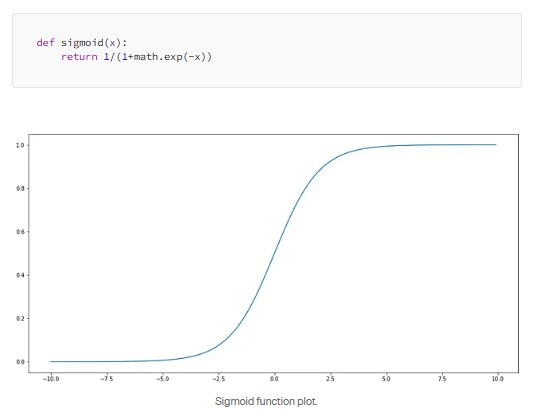

**FEED FORWARD**: Ahora que tenemos los elementos básicos para diseñar el perceptrón, debemos pasar los datos de entrada a través del perceptrón. Este paso se llama feed forward. Primero calculamos la suma ponderada de las entradas y luego pasamos el resultado a través de la función de activación.

La suma ponderada es simplemente el producto escalar entre el vector de pesos y las entradas, luego lo pasamos a través de la función sigmoidea:


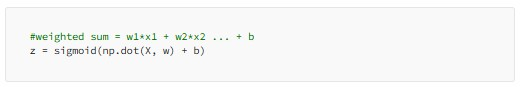

Finalmente debemos aplicar la activación para predecir la salida como 0 o 1:

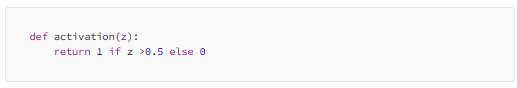

**ENTRENAMIENTO**

Hasta ahora sólo hemos podido pasar los datos de entrada a través del perceptrón sin saber si el perceptrón es correcto o no. La fase de entrenamiento es crucial para hacer que el perceptrón sea más preciso.

El proceso de entrenamiento implica actualizar los pesos del perceptrón para un número de iteraciones (épocas). En cada época, calculamos el error de la salida en relación con el valor real del objetivo para actualizar los pesos y minimizar el error:


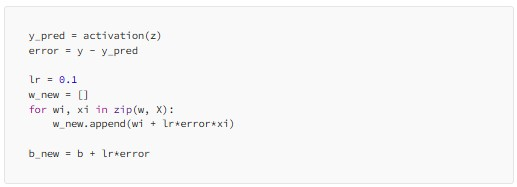

*Nota : lr es la tasa de aprendizaje (veremos más adelante que es esto)y establecemos su valor en 0,1, pero podría ser otro valor dependiendo del problema.*

Hasta ahora, hemos visto las partes del perceptrón y cómo funcionan. A continuación, reuniremos todo lo que hemos aprendido para crear la clase Perceptrón y utilizaremos un conjunto de datos reales (set de datos IRIS) para verificar cómo funciona el perceptrón.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn import datasets

In [7]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [8]:
class Perceptron():

    def __init__(self,input_size = 2, lr = 0.01, epochs = 20):
        #setting default parameters
        self.lr = lr
        self.epochs = epochs
        self.input_size = input_size
        self.w = np.random.uniform(-1, 1, size=(input_size))
        self.bias = random.uniform(-1,1)
        self.misses = []

    def predict(self, X):
        z = sigmoid(np.dot(X, self.w) + self.bias)
        return (z > 0.5).astype(int)

    def fit(self, X, y):

        for epoch in range(self.epochs):
            miss = 0
            for yi, xi in zip(y, X):
                y_pred = self.predict(xi)
                #update the weights to minimize error
                error = yi - y_pred
                self.w += self.lr*error*xi
                self.bias += self.lr*error
                miss += int(error != 0.0)
            #get the number of missclassifications of each epoch
            self.misses.append(miss)

Ahora, utilizaremos la implementación del perceptrón sobre el conjunto de datos del iris de la biblioteca scikit-learn:

In [9]:

iris = datasets.load_iris()
X = iris.data
y = iris.target

Los datos se componen de 4 características (Longitud del sépalo, Ancho del sépalo, Longitud del pétalo y Ancho del pétalo) y 150 muestras divididas en 3 clasificaciones (Setosa, Versicolor y Virginica). Para simplificar, solo utilizaremos 2 características (Longitud del sépalo y Longitud del pétalo) y las muestras Setosa y Versicolor:

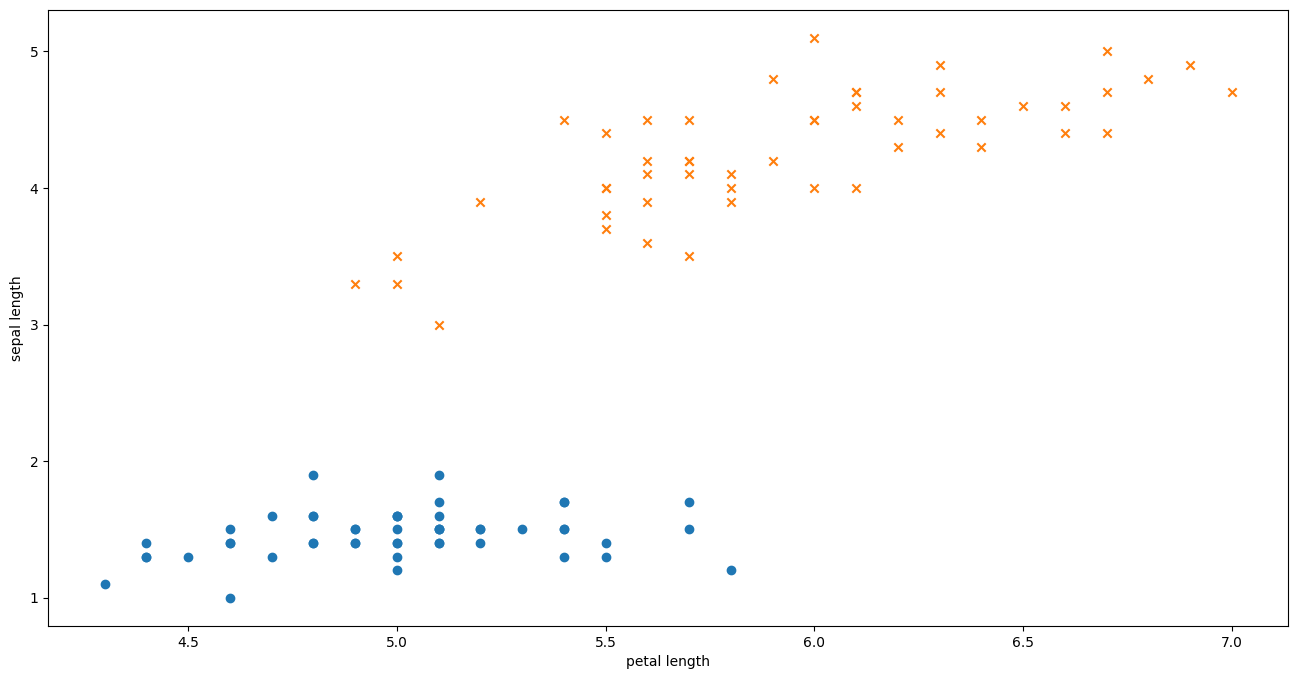

In [10]:
X = X[:100, [0,2]]
y = y[y<2]

# plot the data
plt.figure(figsize=(16,8))
plt.scatter(X[:50,0], X[:50,1], marker='o', label='setosa')
plt.scatter(X[50:,0], X[50:,1], marker='x', label='virginica')
plt.ylabel('sepal length')
plt.xlabel('petal length')
plt.show()

**OBJETIVO:** Entonces, usaremos nuestro PERCEPTRÓN para clasificar flores IRIS, Setosa y Versicolor, a partir de las dos características (Longitud del sépalo y Longitud del pétalo).

Para hacer esto, debemos entrenar el perceptrón usando los datos etiquetados (X, y) y ver cómo funciona:

In [11]:
perceptron = Perceptron()
perceptron.fit(X,y)
print(perceptron.w, perceptron.bias)

[-0.05216285  0.11140505] -0.011047485044302164


De esta manera obtuvimos los pesos y bias óptimos del entrenamiento. Pero, ¿qué tan bien se desempeñó el perceptrón en términos de clasificaciones erróneas? Para ello, graficaremos los errores de la clase del perceptrón:

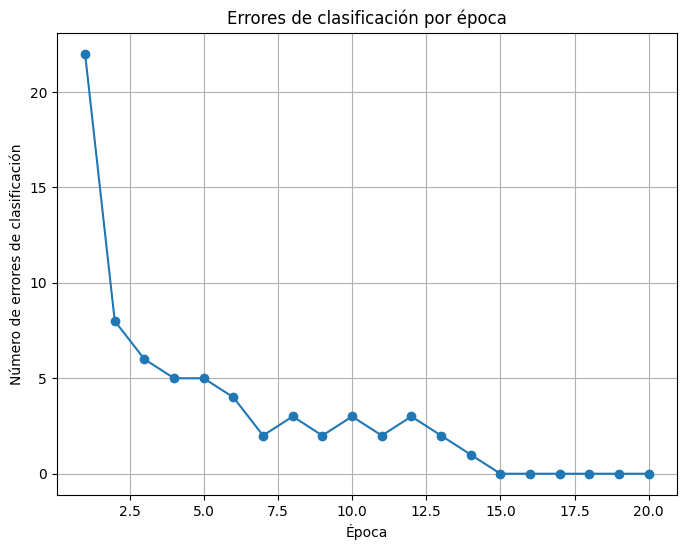

In [12]:
# Graficar las errores en las clasificaciones
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(perceptron.misses) + 1), perceptron.misses, marker='o', linestyle='-')
plt.title('Errores de clasificación por época')
plt.xlabel('Época')
plt.ylabel('Número de errores de clasificación')
plt.grid()
plt.show()

Como podemos ver, el perceptrón falla en las primeras épocas y aprende continuamente hasta que no comete ningún error al final del entrenamiento.

**DESAFIO:** ejecuta el PERCEPTRÓN cambiando el Learning Rate (lr).